In [1]:
from typing import List, TypedDict

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_huggingface import HuggingFaceEndpoint
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

C:\Users\itssp\AppData\Local\Temp\ipykernel_18396\2623255828.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
D:\Downloads\CRAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6338.97it/s]


In [3]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model_name="llama-3.1-8b-instant",
    temperature=0,
)

In [4]:
docs = (
    PyPDFLoader("./Books/book1.pdf").load()
   #PyPDFLoader("./Books/book2.pdf").load(),
   #PyPDFLoader("./Books/book3.pdf").load()
)

In [5]:
len(docs)

758

In [6]:
import sys
print(sys.executable)

D:\Downloads\CRAG\.venv\Scripts\python.exe


In [7]:
import sys
print(sys.executable)

import langchain_community
print("SUCCESS")

D:\Downloads\CRAG\.venv\Scripts\python.exe
SUCCESS


In [8]:
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [9]:
vector_store = FAISS.from_documents(chunks, embeddings)

In [10]:
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={'k':4})

In [11]:
class State(TypedDict):
    question: str
    docs: List[Document]
    answer: str
    strips:List[str]
    kept_strips:List[str]
    refined_context: List[str]

In [12]:
def retrieve(state):
    q = state["question"]
    return {"docs": retriever.invoke(q)}
#


In [14]:
from pydantic import BaseModel
import re
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

class KeepOrDrop(BaseModel):
    keep: bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)


def refine(state: State) -> State:

    q = state["question"]

    # Combine retrieved docs into one context string
    context = "\n\n".join(d.page_content for d in state["docs"]).strip()

    # 1) DECOMPOSITION: context -> sentence strips
    strips = decompose_to_sentences(context)

    # 2) FILTER: keep only relevant strips
    kept: List[str] = []

    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    # 3) RECOMPOSE: glue kept strips back together (internal knowledge)
    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }

In [15]:
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. If not in context, say you don't know."),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)
def generate(state):
    context = "\n\n".join(d.page_content for d in state["docs"])
    out = (prompt | llm).invoke({"question": state["question"], "context": context})
    return {"answer": out.content}

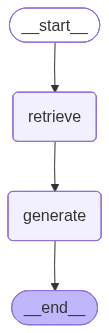

In [16]:
g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("generate", generate)
g.add_edge(START, "retrieve")
g.add_edge("retrieve", "generate")
g.add_edge("generate", END)
app = g.compile()

app

In [17]:
# 5) Run
res = app.invoke({"question": "WHat is a transformer in deep learning.", "docs": [], "answer": ""})
print(res["answer"])

A transformer in deep learning is not explicitly mentioned in the given context. However, the context does mention convolutional neural networks (CNNs) which are a type of neural network that can learn to be invariant to transformations such as translations, scaling, and rotations.

However, in the context of deep learning, a transformer is actually a type of neural network architecture that was introduced in the paper "Attention Is All You Need" by Vaswani et al. in 2017. It is primarily used for natural language processing tasks such as machine translation, text classification, and question answering.

In the context of the given text, it seems that the author is discussing neural networks and their ability to learn invariances, but the term "transformer" is not mentioned.
